# Notebook 5: Modeling

This notebook trains and evaluates three model families on three feature sets using a municipality-grouped protocol: it creates a held-out test split, runs cross-validated MVP comparisons on the training split, performs hyperparameter tuning (RF/XGB) on the training split only, and reports final performance on the held-out test set.

### Inputs (from `datasets/model_ready/`)
- `datasets/model_ready/model_ready_base.csv`
- `datasets/model_ready/model_ready_queen.csv`
- `datasets/model_ready/model_ready_boundary.csv`

### Models compared
- OLS (baseline linear regression)
- Random Forest (RF)
- XGBoost (XGB)


## Imports and reproducibility settings


In [2]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [ ]:
# XGBoost import
import os

_libomp_candidates = [
    "/usr/local/opt/libomp/lib",
    "/opt/homebrew/opt/libomp/lib",
]

for p in _libomp_candidates:
    if os.path.isdir(p):
        os.environ["DYLD_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_LIBRARY_PATH", "")
        os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_FALLBACK_LIBRARY_PATH", "")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(e)

print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", XGBOOST_IMPORT_ERROR)
    print("\nIf this is a libomp error on macOS, run:")
    print("- `brew install libomp`")
    print("Then restart the kernel (Kernel → Restart) and rerun.")


XGBoost available: True


In [ ]:
# Package versions
try:
    from importlib.metadata import version
except Exception:
    from importlib_metadata import version 

pkgs = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "xgboost"]
versions = {}
for p in pkgs:
    try:
        versions[p] = version(p)
    except Exception:
        versions[p] = None

print("Package versions:")
for pkg, ver in versions.items():
    print(f"{pkg}: {ver}")



Package versions:
numpy: 2.4.4
pandas: 2.3.3
matplotlib: 3.10.8
seaborn: 0.13.2
scikit-learn: 1.8.0
xgboost: 3.2.0


### Load datasets


In [10]:
# Load full model-ready datasets (produced by notebook 4)
DATA_DIR = Path("datasets/model_ready/")
BASE_PATH = DATA_DIR / "model_ready_base.csv"
QUEEN_PATH = DATA_DIR / "model_ready_queen.csv"
BOUNDARY_PATH = DATA_DIR / "model_ready_boundary.csv"

base_df_full = pd.read_csv(BASE_PATH, low_memory=False)
queen_df_full = pd.read_csv(QUEEN_PATH, low_memory=False)
boundary_df_full = pd.read_csv(BOUNDARY_PATH, low_memory=False)

# Create a held-out test split (municipality-grouped, 80/20 by municipalities)
GROUP_COL = "gm_naam"
RANDOM_STATE = 42
TEST_FRACTION = 0.20

for tag, df in {"base": base_df_full, "queen": queen_df_full, "boundary": boundary_df_full}.items():
    if GROUP_COL not in df.columns:
        raise KeyError(f"Expected grouping column '{GROUP_COL}' in {tag} dataset.")

base_munis = set(base_df_full[GROUP_COL].dropna().unique().tolist())
queen_munis = set(queen_df_full[GROUP_COL].dropna().unique().tolist())
boundary_munis = set(boundary_df_full[GROUP_COL].dropna().unique().tolist())

if not (base_munis == queen_munis == boundary_munis):
    raise ValueError("Municipality sets differ across datasets; cannot do a consistent grouped split.")

munis = sorted(base_munis)
rng = np.random.default_rng(RANDOM_STATE)

test_n_munis = max(1, int(round(TEST_FRACTION * len(munis))))
test_munis = set(rng.choice(munis, size=test_n_munis, replace=False).tolist())
train_munis = set(munis) - test_munis

def split_by_muni(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    is_test = df[GROUP_COL].isin(test_munis)
    return df.loc[~is_test].copy(), df.loc[is_test].copy()

base_train_df, base_test_df = split_by_muni(base_df_full)
queen_train_df, queen_test_df = split_by_muni(queen_df_full)
boundary_train_df, boundary_test_df = split_by_muni(boundary_df_full)

# Verify identical municipality split across all datasets
base_train_munis = set(base_train_df[GROUP_COL].dropna().unique().tolist())
base_test_munis = set(base_test_df[GROUP_COL].dropna().unique().tolist())
queen_train_munis = set(queen_train_df[GROUP_COL].dropna().unique().tolist())
queen_test_munis = set(queen_test_df[GROUP_COL].dropna().unique().tolist())
boundary_train_munis = set(boundary_train_df[GROUP_COL].dropna().unique().tolist())
boundary_test_munis = set(boundary_test_df[GROUP_COL].dropna().unique().tolist())

print("=== Held-out test split audit (municipality-grouped) ===")
print(f"Municipalities (train): {len(train_munis)} | (test): {len(test_munis)} | (total): {len(munis)}")
print("Train muni sets match across datasets:", base_train_munis == queen_train_munis == boundary_train_munis)
print("Test muni sets match across datasets:", base_test_munis == queen_test_munis == boundary_test_munis)

# Audit summary (printed; not saved)
for tag, df_tr, df_te in [
    ("base", base_train_df, base_test_df),
    ("queen", queen_train_df, queen_test_df),
    ("boundary", boundary_train_df, boundary_test_df),
]:
    n_total = len(df_tr) + len(df_te)
    print(f"\n[{tag}] Rows: total={n_total}, train={len(df_tr)} ({len(df_tr)/n_total:.1%}), test={len(df_te)} ({len(df_te)/n_total:.1%})")
    print(
        f"[{tag}] Municipalities: train={len(set(df_tr[GROUP_COL].dropna().unique()))} ({len(set(df_tr[GROUP_COL].dropna().unique()))/len(munis):.1%}), "
        f"test={len(set(df_te[GROUP_COL].dropna().unique()))} ({len(set(df_te[GROUP_COL].dropna().unique()))/len(munis):.1%})"
    )

# Save splits for reproducibility (same municipalities across all three feature sets)
base_train_df.to_csv(DATA_DIR / "model_ready_base_train.csv", index=False)
base_test_df.to_csv(DATA_DIR / "model_ready_base_test.csv", index=False)
queen_train_df.to_csv(DATA_DIR / "model_ready_queen_train.csv", index=False)
queen_test_df.to_csv(DATA_DIR / "model_ready_queen_test.csv", index=False)
boundary_train_df.to_csv(DATA_DIR / "model_ready_boundary_train.csv", index=False)
boundary_test_df.to_csv(DATA_DIR / "model_ready_boundary_test.csv", index=False)

print("\nSaved train/test splits under datasets/:")
print("-", DATA_DIR / "model_ready_base_train.csv")
print("-", DATA_DIR / "model_ready_base_test.csv")
print("-", DATA_DIR / "model_ready_queen_train.csv")
print("-", DATA_DIR / "model_ready_queen_test.csv")
print("-", DATA_DIR / "model_ready_boundary_train.csv")
print("-", DATA_DIR / "model_ready_boundary_test.csv")

# From this point onward, MVP modeling uses TRAIN SPLIT ONLY
base_df = base_train_df
queen_df = queen_train_df
boundary_df = boundary_train_df


=== Held-out test split audit (municipality-grouped) ===
Municipalities (train): 273 | (test): 68 | (total): 341
Train muni sets match across datasets: True
Test muni sets match across datasets: True

[base] Rows: total=14494, train=11735 (81.0%), test=2759 (19.0%)
[base] Municipalities: train=273 (80.1%), test=68 (19.9%)

[spatial] Rows: total=14494, train=11735 (81.0%), test=2759 (19.0%)
[spatial] Municipalities: train=273 (80.1%), test=68 (19.9%)

[boundary] Rows: total=14494, train=11735 (81.0%), test=2759 (19.0%)
[boundary] Municipalities: train=273 (80.1%), test=68 (19.9%)

Saved train/test splits under datasets/:
- datasets/model_ready/model_ready_base_train.csv
- datasets/model_ready/model_ready_base_test.csv
- datasets/model_ready/model_ready_spatial_train.csv
- datasets/model_ready/model_ready_spatial_test.csv
- datasets/model_ready/model_ready_boundary_train.csv
- datasets/model_ready/model_ready_boundary_test.csv


### Inspect columns and select target / ID / grouping variables


In [6]:
# Target/grouping variables
TARGET_COL = "log_crime_count"
GROUP_COL = "gm_naam"

if TARGET_COL not in base_df.columns or TARGET_COL not in queen_df.columns:
    raise KeyError(f"Expected '{TARGET_COL}' in both datasets.")
if GROUP_COL not in base_df.columns:
    raise KeyError(f"Expected grouping column '{GROUP_COL}' in dataset.")


### Define feature matrices


In [ ]:
# Feature selection (numeric predictors only; exclude identifiers and leakage columns)

# Exclusion columns:
# 'gwb_code_10', 'gwb_code_8', 'regio', 'gm_naam', 'recs', 'gwb_code', 'ind_wbi',
# 'merge_key', 'ID', 'SoortMisdrijf', 'Perioden', 'GeregistreerdeMisdrijven_1',
# 'centroid_x', 'centroid_y', 'crime_count', 'geometry', 'log_crime_count'

ID_COLS_BASE = [
    "gwb_code_10",
    "gwb_code_8",
    "gwb_code",
    'ind_wbi',
    "merge_key",
    "regio",
    "gm_naam",
    "ID",
    "Perioden",
    "SoortMisdrijf",
    "recs",
    "centroid_x",
    "centroid_y",
]
ID_COLS_SPATIAL = ID_COLS_BASE.copy()  # legacy name; kept for backward-compatibility in older cached outputs
ID_COLS_QUEEN = ID_COLS_BASE.copy()
ID_COLS_BOUNDARY = ID_COLS_BASE.copy()

RAW_TARGET_LIKE = {
    "crime_count",
    "GeregistreerdeMisdrijven_1",
}

LEAKAGE_PATTERNS = [
    r"spillover_spec",
    r"spillover_target",
    r"target_lag",
    r"lag_y",
    r"spillover_lag",
    r"lag_.*crime",
    r"crime.*lag",
]
LEAKAGE_REGEX = re.compile("|".join(LEAKAGE_PATTERNS), flags=re.IGNORECASE)

def select_numeric_predictors(
    df: pd.DataFrame, target: str, id_cols: List[str]
) -> Tuple[pd.DataFrame, pd.Series, Dict[str, Any]]:
    df = df.copy()

    leak = [c for c in df.columns if LEAKAGE_REGEX.search(c)]
    exclude = set([c for c in id_cols if c in df.columns]) | set(leak) | set(RAW_TARGET_LIKE) | {target}

    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    feature_cols = [c for c in num_cols if c not in exclude]

    X = df[feature_cols].copy()
    y = df[target].copy()

    assert target not in X.columns
    assert not any(LEAKAGE_REGEX.search(c) for c in X.columns)

    info = {
        "n_features": len(feature_cols),
        "queen_lag_cols": [c for c in feature_cols if c.startswith("queen_lag_")],
        "boundary_lag_cols": [c for c in feature_cols if c.startswith("boundary_lag_")],
        "excluded_leakage_cols": leak,
    }
    return X, y, info


X_base, y_base, info_base = select_numeric_predictors(base_df, TARGET_COL, ID_COLS_BASE)
X_queen, y_queen, info_queen = select_numeric_predictors(queen_df, TARGET_COL, ID_COLS_QUEEN)
X_boundary, y_boundary, info_boundary = select_numeric_predictors(boundary_df, TARGET_COL, ID_COLS_BOUNDARY)

print("Selected features:")
print("- base:", X_base.shape)
print("- queen:", X_queen.shape)
print("- boundary:", X_boundary.shape)
print("Spillover columns:")
print("- queen lags:", len(info_queen["queen_lag_cols"]))
print("- boundary lags:", len(info_boundary["boundary_lag_cols"]))


Selected features:
- base: (11735, 83)
- spatial: (11735, 95)
- boundary: (11735, 89)
Spillover columns:
- spatial queen lags: 12
- boundary boundary lags: 6


### Define leakage-safe pipelines


In [34]:
# Creates a linear regression pipeline with median imputation and standard scaling.
def make_ols_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

# Creates a random forest regression pipeline with median imputation.
def make_rf_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

# Creates an XGBoost regression pipeline with median imputation; checks XGBoost availability.
def make_xgb_pipeline() -> Pipeline:
    if not XGBOOST_AVAILABLE:
        raise ImportError(
            "xgboost is not available. Install it and rerun. "
            f"Import error was: {XGBOOST_IMPORT_ERROR}"
        )
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


### Cross-validation strategy


In [35]:
def make_cv(groups: Optional[pd.Series]) -> Tuple[Any, str]:
    if groups is not None:
        return GroupKFold(n_splits=5), f"GroupKFold(n_splits=5) on '{groups.name}'"
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), "KFold(n_splits=5, shuffle=True, random_state=42)"

def print_fold_diagnostics(cv, X: pd.DataFrame, y: pd.Series, groups: Optional[pd.Series]):
    for tr, va in cv.split(X, y, groups):
        if groups is None:
            continue
        gtr = set(groups.iloc[tr].astype(str))
        gva = set(groups.iloc[va].astype(str))
        overlap = gtr.intersection(gva)
        if overlap:
            raise ValueError("Group overlap detected between train and validation folds")


groups_base = base_df[GROUP_COL] if GROUP_COL and GROUP_COL in base_df.columns else None
groups_queen = queen_df[GROUP_COL] if GROUP_COL and GROUP_COL in queen_df.columns else None
groups_boundary = boundary_df[GROUP_COL] if GROUP_COL and GROUP_COL in boundary_df.columns else None

cv_base, cv_base_desc = make_cv(groups_base)
cv_queen, cv_queen_desc = make_cv(groups_queen)
cv_boundary, cv_boundary_desc = make_cv(groups_boundary)

print_fold_diagnostics(cv_base, X_base, y_base, groups_base)
print_fold_diagnostics(cv_queen, X_queen, y_queen, groups_queen)
print_fold_diagnostics(cv_boundary, X_boundary, y_boundary, groups_boundary)


## Helper functions for evaluation


In [36]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_cv_oof(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    groups: Optional[pd.Series],
    model_name: str,
    dataset_name: str,
    id_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    oof_pred = np.full(len(y), np.nan, dtype=float)
    fold_rows = []

    for fold, (tr, va) in enumerate(cv.split(X, y, groups)):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        X_va, y_va = X.iloc[va], y.iloc[va]

        model_fold = Pipeline(steps=model.steps)
        model_fold.fit(X_tr, y_tr)

        pred_tr = model_fold.predict(X_tr)
        pred_va = model_fold.predict(X_va)

        oof_pred[va] = pred_va

        fold_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "fold": fold,
            "n_train": len(tr),
            "n_val": len(va),
            "rmse_train": rmse(y_tr, pred_tr),
            "rmse_val": rmse(y_va, pred_va),
            "mae_train": float(mean_absolute_error(y_tr, pred_tr)),
            "mae_val": float(mean_absolute_error(y_va, pred_va)),
            "r2_train": float(r2_score(y_tr, pred_tr)),
            "r2_val": float(r2_score(y_va, pred_va)),
        })

    fold_df = pd.DataFrame(fold_rows)

    oof_df = id_df.copy()
    oof_df["dataset"] = dataset_name
    oof_df["model"] = model_name
    oof_df["y_true"] = y.values
    oof_df["y_pred_oof"] = oof_pred
    oof_df["residual"] = oof_df["y_true"] - oof_df["y_pred_oof"]
    oof_df["abs_error"] = oof_df["residual"].abs()

    if np.isnan(oof_pred).any():
        raise RuntimeError("OOF predictions contain NaN")

    return fold_df, oof_df


def summarize_folds(fold_df: pd.DataFrame) -> pd.DataFrame:
    return (
        fold_df.groupby(["dataset", "model"])
        .agg(
            rmse_val_mean=("rmse_val", "mean"),
            rmse_val_std=("rmse_val", "std"),
            mae_val_mean=("mae_val", "mean"),
            mae_val_std=("mae_val", "std"),
            r2_val_mean=("r2_val", "mean"),
            r2_val_std=("r2_val", "std"),
        )
        .reset_index()
        .sort_values(["dataset", "rmse_val_mean"])
    )


### Fit and evaluate OLS / RF / XGBoost


In [37]:
# Context columns for diagnostics
KEEP_CONTEXT_COLS = [c for c in ["gwb_code_10", "gm_naam", "regio", "a_inw", "crime_count"] if c in base_df.columns]

id_base = base_df[KEEP_CONTEXT_COLS].copy() if KEEP_CONTEXT_COLS else pd.DataFrame(index=base_df.index)
id_queen = queen_df[KEEP_CONTEXT_COLS].copy() if KEEP_CONTEXT_COLS else pd.DataFrame(index=queen_df.index)
id_boundary = boundary_df[KEEP_CONTEXT_COLS].copy() if KEEP_CONTEXT_COLS else pd.DataFrame(index=boundary_df.index)

# Run MVP CV once (train split only)
models = {
    "OLS": make_ols_pipeline(),
    "RF": make_rf_pipeline(),
}
if XGBOOST_AVAILABLE:
    models["XGB"] = make_xgb_pipeline()

fold_tables = []
oof_tables = []

print("Running MVP CV (train split only)...")
for name, pipe in models.items():
    fdf, oof = evaluate_cv_oof(pipe, X_base, y_base, cv_base, groups_base, name, "base", id_base)
    fold_tables.append(fdf)
    oof_tables.append(oof)

for name, pipe in models.items():
    fdf, oof = evaluate_cv_oof(pipe, X_queen, y_queen, cv_queen, groups_queen, name, "queen", id_queen)
    fold_tables.append(fdf)
    oof_tables.append(oof)

for name, pipe in models.items():
    fdf, oof = evaluate_cv_oof(pipe, X_boundary, y_boundary, cv_boundary, groups_boundary, name, "boundary", id_boundary)
    fold_tables.append(fdf)
    oof_tables.append(oof)

fold_metrics = pd.concat(fold_tables, ignore_index=True)
oof_predictions = pd.concat(oof_tables, ignore_index=True)

summary = summarize_folds(fold_metrics)
print("\nMVP fold-level summary (validation metrics):")
print(summary.to_string(index=False))


Running MVP CV (train split only)...

MVP fold-level summary (validation metrics):
 dataset model  rmse_val_mean  rmse_val_std  mae_val_mean  mae_val_std  r2_val_mean  r2_val_std
    base   XGB       0.582898      0.012008      0.426429     0.004681     0.823979    0.009740
    base    RF       0.603115      0.011830      0.439986     0.004462     0.811664    0.007456
    base   OLS       0.724832      0.025613      0.540249     0.010857     0.728033    0.014174
boundary   XGB       0.580907      0.009739      0.425424     0.004860     0.825143    0.010045
boundary    RF       0.603104      0.011000      0.440565     0.005084     0.811629    0.008456
boundary   OLS       0.719099      0.026498      0.537402     0.011720     0.732268    0.015657
 spatial   XGB       0.578014      0.008215      0.425189     0.003216     0.826745    0.012243
 spatial    RF       0.596650      0.007910      0.439561     0.005329     0.815493    0.011081
 spatial   OLS       0.704073      0.024235      0.52

### Compare models on base vs queen vs boundary



MVP model comparison (mean CV metrics):
 dataset model  mean_RMSE  std_RMSE  mean_MAE  std_MAE  mean_R2   std_R2
    base   XGB   0.582898  0.012008  0.426429 0.004681 0.823979 0.009740
    base    RF   0.603115  0.011830  0.439986 0.004462 0.811664 0.007456
    base   OLS   0.724832  0.025613  0.540249 0.010857 0.728033 0.014174
boundary   XGB   0.580907  0.009739  0.425424 0.004860 0.825143 0.010045
boundary    RF   0.603104  0.011000  0.440565 0.005084 0.811629 0.008456
boundary   OLS   0.719099  0.026498  0.537402 0.011720 0.732268 0.015657
 spatial   XGB   0.578014  0.008215  0.425189 0.003216 0.826745 0.012243
 spatial    RF   0.596650  0.007910  0.439561 0.005329 0.815493 0.011081
 spatial   OLS   0.704073  0.024235  0.526815 0.009861 0.743397 0.012860


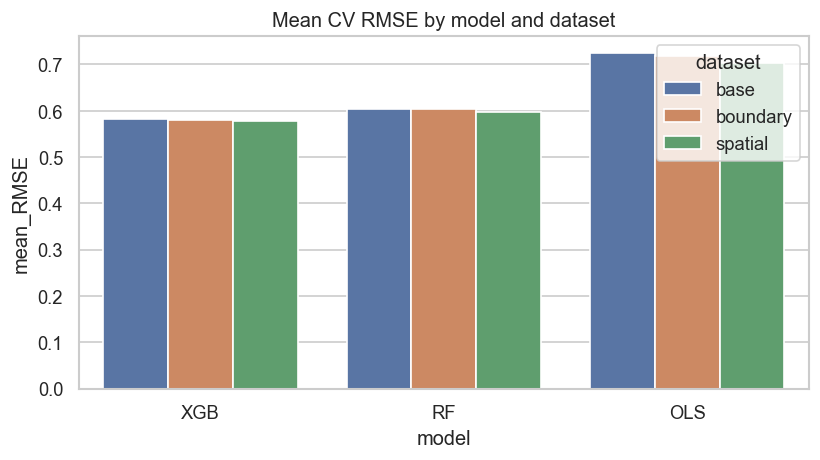

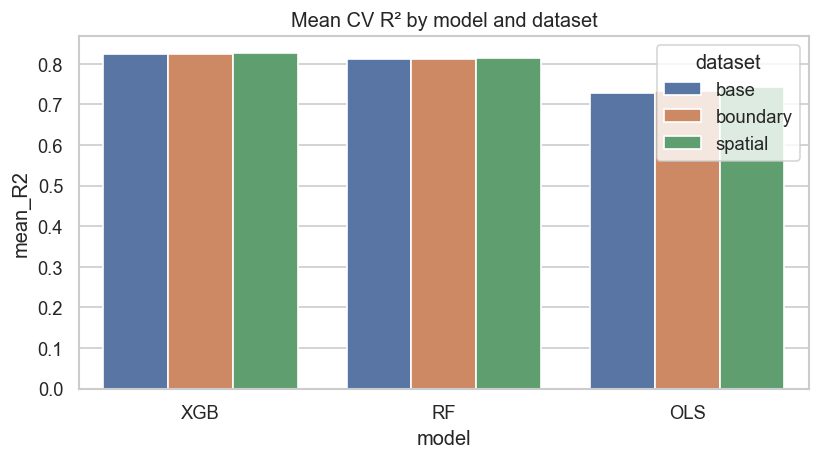

In [38]:
comparison = summary.rename(columns={
    "rmse_val_mean": "mean_RMSE",
    "rmse_val_std": "std_RMSE",
    "mae_val_mean": "mean_MAE",
    "mae_val_std": "std_MAE",
    "r2_val_mean": "mean_R2",
    "r2_val_std": "std_R2",
}).copy()

print("\nMVP model comparison (mean CV metrics):")
print(comparison.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="model", y="mean_RMSE", hue="dataset")
plt.title("Mean CV RMSE by model and dataset")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="model", y="mean_R2", hue="dataset")
plt.title("Mean CV R² by model and dataset")
plt.tight_layout()
plt.show()



Top OLS coefficients (base, full fit):


,feature,coef
75,a_opp_ha,7.602484
76,a_lan_ha,-7.189829
1,a_inw,-6.474060
66,a_pau,-2.518181
2,a_man,2.463173
57,a_bedv,2.267759
67,a_bst_b,2.207433
15,a_neu_al,1.842799
16,a_geb_nl,1.713022
9,a_ongeh,-1.355399



Top RF permutation importances (val fold): base


,feature,importance
26,a_1p_hh,0.256434
57,a_bedv,0.231306
81,ste_oad,0.047039
60,a_bed_gi,0.041127
33,a_vastg,0.028531
15,a_neu_al,0.022734
74,g_3km_sc,0.017374
75,a_opp_ha,0.005431
76,a_lan_ha,0.004223
20,a_gbl_ne,0.003293


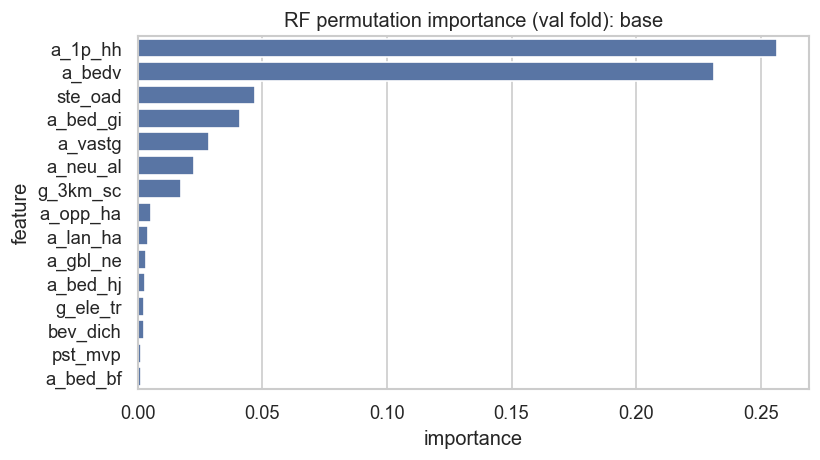


Top RF permutation importances (val fold): spatial


,feature,importance
26,a_1p_hh,0.261242
57,a_bedv,0.167731
60,a_bed_gi,0.039163
33,a_vastg,0.030770
87,queen_lag_sum_a_bedv,0.027191
15,a_neu_al,0.025976
85,queen_lag_sum_a_woning,0.014244
81,ste_oad,0.009400
74,g_3km_sc,0.004697
20,a_gbl_ne,0.002675


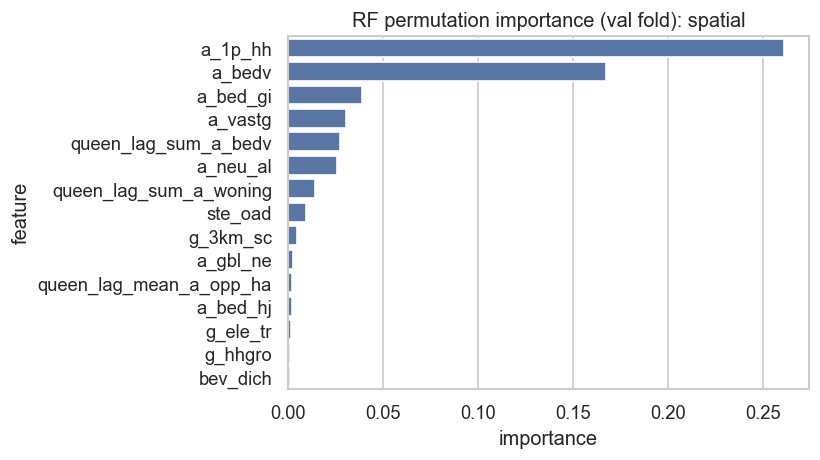


Top XGB feature importances (base, full fit):


,feature,importance
26,a_1p_hh,0.404263
57,a_bedv,0.128540
65,a_bed_ru,0.088799
20,a_gbl_ne,0.050496
15,a_neu_al,0.046355
60,a_bed_gi,0.026006
14,a_eur_al,0.021370
33,a_vastg,0.018953
81,ste_oad,0.011423
74,g_3km_sc,0.007957


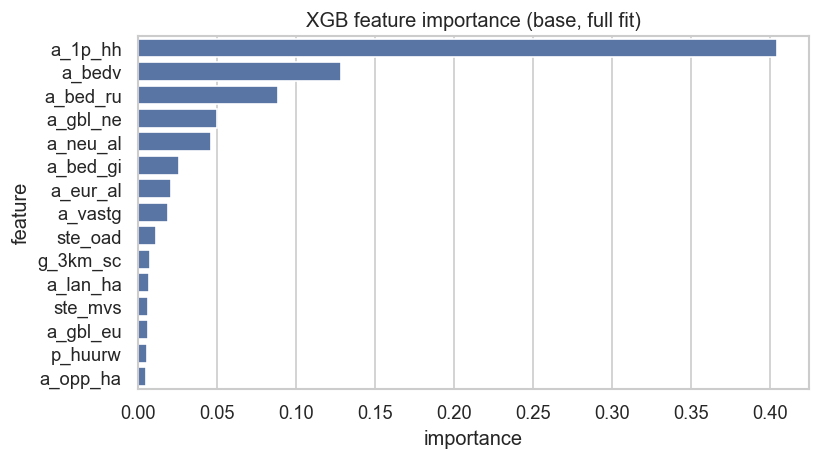


Top XGB feature importances (spatial, full fit):


,feature,importance
26,a_1p_hh,0.337501
57,a_bedv,0.160286
65,a_bed_ru,0.098553
20,a_gbl_ne,0.048879
15,a_neu_al,0.036640
60,a_bed_gi,0.027958
14,a_eur_al,0.019986
33,a_vastg,0.019470
87,queen_lag_sum_a_bedv,0.014972
85,queen_lag_sum_a_woning,0.011861


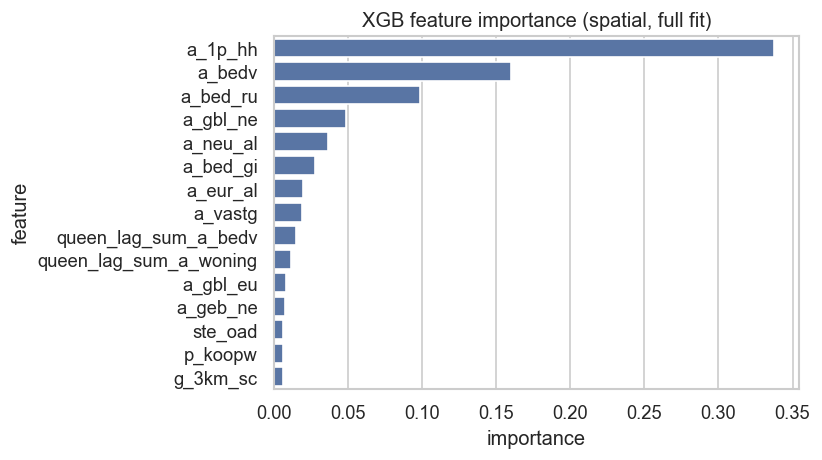

In [39]:
def fit_full(model: Pipeline, X: pd.DataFrame, y: pd.Series) -> Pipeline:
    m = Pipeline(steps=model.steps)
    return m.fit(X, y)

# OLS coefficients (scaled)
ols_full_base = fit_full(make_ols_pipeline(), X_base, y_base)
coef = ols_full_base.named_steps["model"].coef_
ols_coef_df = pd.DataFrame({"feature": X_base.columns, "coef": coef}).sort_values("coef", key=np.abs, ascending=False)
print("\nTop OLS coefficients (base, full fit):")
display(ols_coef_df.head(20))

# RF permutation importance on one validation fold
def rf_perm_imp_one_fold(X, y, cv, groups, tag: str):
    pipe = make_rf_pipeline()
    tr, va = next(iter(cv.split(X, y, groups)))
    pipe.fit(X.iloc[tr], y.iloc[tr])

    try:
        r = permutation_importance(
            pipe,
            X.iloc[va],
            y.iloc[va],
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    except Exception as e:
        print("Permutation importance failed; retrying single-process. Error:", repr(e))
        r = permutation_importance(
            pipe,
            X.iloc[va],
            y.iloc[va],
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )

    imp = pd.DataFrame({"feature": X.columns, "importance": r.importances_mean}).sort_values("importance", ascending=False)
    print(f"\nTop RF permutation importances (val fold): {tag}")
    display(imp.head(15))

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp.head(15), x="importance", y="feature")
    plt.title(f"RF permutation importance (val fold): {tag}")
    plt.tight_layout()
    plt.show()

rf_perm_imp_one_fold(X_base, y_base, cv_base, groups_base, "base")
rf_perm_imp_one_fold(X_queen, y_queen, cv_queen, groups_queen, "queen")

if XGBOOST_AVAILABLE:
    xgb_full_base = fit_full(make_xgb_pipeline(), X_base, y_base)
    xgb_model = xgb_full_base.named_steps["model"]
    imp = pd.DataFrame({"feature": X_base.columns, "importance": xgb_model.feature_importances_}).sort_values("importance", ascending=False)
    print("\nTop XGB feature importances (base, full fit):")
    display(imp.head(15))

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp.head(15), x="importance", y="feature")
    plt.title("XGB feature importance (base, full fit)")
    plt.tight_layout()
    plt.show()

    xgb_full_queen = fit_full(make_xgb_pipeline(), X_queen, y_queen)
    xgb_model_q = xgb_full_queen.named_steps["model"]
    imp_q = pd.DataFrame({"feature": X_queen.columns, "importance": xgb_model_q.feature_importances_}).sort_values("importance", ascending=False)
    print("\nTop XGB feature importances (queen, full fit):")
    display(imp_q.head(15))

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp_q.head(15), x="importance", y="feature")
    plt.title("XGB feature importance (queen, full fit)")
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost not available")


### MVP summary (train split CV only)

This notebook provides the MVP cross-validated comparison on the **training split only**, followed by tuning, refit-on-full-train, and **final evaluation on the held-out test set**.


In [40]:
best_overall = comparison.sort_values("mean_RMSE").iloc[0]
print("Best MVP configuration by mean CV RMSE (train split only):")
print(best_overall.to_string())


Best MVP configuration by mean CV RMSE (train split only):
dataset       spatial
model             XGB
mean_RMSE    0.578014
std_RMSE     0.008215
mean_MAE     0.425189
std_MAE      0.003216
mean_R2      0.826745
std_R2       0.012243


In [ ]:
# Show the compact MVP comparison table
comparison

,dataset,model,mean_RMSE,std_RMSE,mean_MAE,std_MAE,mean_R2,std_R2
2,base,XGB,0.582898,0.012008,0.426429,0.004681,0.823979,0.009740
1,base,RF,0.603115,0.011830,0.439986,0.004462,0.811664,0.007456
0,base,OLS,0.724832,0.025613,0.540249,0.010857,0.728033,0.014174
5,boundary,XGB,0.580907,0.009739,0.425424,0.004860,0.825143,0.010045
4,boundary,RF,0.603104,0.011000,0.440565,0.005084,0.811629,0.008456
3,boundary,OLS,0.719099,0.026498,0.537402,0.011720,0.732268,0.015657
8,spatial,XGB,0.578014,0.008215,0.425189,0.003216,0.826745,0.012243
7,spatial,RF,0.596650,0.007910,0.439561,0.005329,0.815493,0.011081
6,spatial,OLS,0.704073,0.024235,0.526815,0.009861,0.743397,0.012860


## Improving the models

### Hyperparameter tuning

RF and XGBoost are tuned using `RandomizedSearchCV` on the **training split only** (municipality-grouped CV).


In [42]:
# Tuning search spaces
rf_param_grid = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8],
    "model__bootstrap": [True],
}

if not XGBOOST_AVAILABLE:
    raise ImportError(f"XGBoost unavailable; cannot run XGB tuning. Error: {XGBOOST_IMPORT_ERROR}")

xgb_param_grid = {
    "model__n_estimators": [300, 500, 800, 1000],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0.5, 1, 2, 5],
}

hp_overview = pd.concat(
    [
        pd.DataFrame({"model": "RF", "hyperparameter": list(rf_param_grid.keys()), "values": [str(v) for v in rf_param_grid.values()]}),
        pd.DataFrame({"model": "XGB", "hyperparameter": list(xgb_param_grid.keys()), "values": [str(v) for v in xgb_param_grid.values()]}),
    ],
    ignore_index=True,
)
print("\nHyperparameter search space overview:")
display(hp_overview)

# Helper: tune one model on one dataset

def run_random_search(estimator: Pipeline, param_grid: dict, X, y, cv, groups, n_iter: int, label: str):
    print(f"\n--- Tuning {label} ---")
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=1,  # keep single-process (BrokenProcessPool safety)
        random_state=RANDOM_STATE,
        verbose=1,
        return_train_score=True,
    )
    search.fit(X, y, **({"groups": groups} if groups is not None else {}))

    res = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
    best_rmse = float(-search.best_score_)

    print("Best params:")
    print(search.best_params_)
    print(f"Best CV RMSE: {best_rmse:.4f}")

    return search.best_estimator_, res, best_rmse

# Keep tuned RMSEs for the untuned→tuned delta table later
best_tuned_rmse = {}

# Tuned RF
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_best_base, rf_res_base, rf_rmse_base = run_random_search(rf_pipe, rf_param_grid, X_base, y_base, cv_base, groups_base, n_iter=30, label="RF (base)")
rf_best_queen, rf_res_queen, rf_rmse_queen = run_random_search(rf_pipe, rf_param_grid, X_queen, y_queen, cv_queen, groups_queen, n_iter=30, label="RF (queen)")
rf_best_boundary, rf_res_boundary, rf_rmse_boundary = run_random_search(rf_pipe, rf_param_grid, X_boundary, y_boundary, cv_boundary, groups_boundary, n_iter=30, label="RF (boundary)")

best_tuned_rmse[("RF", "base")] = rf_rmse_base
best_tuned_rmse[("RF", "queen")] = rf_rmse_queen
best_tuned_rmse[("RF", "boundary")] = rf_rmse_boundary

print("\nTop RF tuning results (base):")
display(rf_res_base[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))

print("\nTop RF tuning results (spatial):")
display(rf_res_spatial[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))

print("\nTop RF tuning results (boundary):")
display(rf_res_boundary[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))

# Tuned XGB
xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model",
        xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
])

xgb_best_base, xgb_res_base, xgb_rmse_base = run_random_search(xgb_pipe, xgb_param_grid, X_base, y_base, cv_base, groups_base, n_iter=40, label="XGB (base)")
xgb_best_queen, xgb_res_queen, xgb_rmse_queen = run_random_search(xgb_pipe, xgb_param_grid, X_queen, y_queen, cv_queen, groups_queen, n_iter=40, label="XGB (queen)")
xgb_best_boundary, xgb_res_boundary, xgb_rmse_boundary = run_random_search(xgb_pipe, xgb_param_grid, X_boundary, y_boundary, cv_boundary, groups_boundary, n_iter=40, label="XGB (boundary)")

best_tuned_rmse[("XGB", "base")] = xgb_rmse_base
best_tuned_rmse[("XGB", "queen")] = xgb_rmse_queen
best_tuned_rmse[("XGB", "boundary")] = xgb_rmse_boundary

print("\nTop XGB tuning results (base):")
display(xgb_res_base[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))

print("\nTop XGB tuning results (spatial):")
display(xgb_res_spatial[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))

print("\nTop XGB tuning results (boundary):")
display(xgb_res_boundary[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))

# Untuned → tuned RMSE delta table (tree models only)
delta_rows = []
for model_name in ["RF", "XGB"]:
    for dataset_name in ["base", "spatial", "boundary"]:
        mvp_row = summary[(summary["model"] == model_name) & (summary["dataset"] == dataset_name)]
        if len(mvp_row) != 1:
            continue
        mvp_rmse = float(mvp_row["rmse_val_mean"].iloc[0])
        tuned_rmse = best_tuned_rmse.get((model_name, dataset_name), np.nan)
        delta_rows.append(
            {
                "model": model_name,
                "dataset": dataset_name,
                "mvp_cv_rmse": mvp_rmse,
                "tuned_cv_rmse": float(tuned_rmse) if np.isfinite(tuned_rmse) else np.nan,
                "rmse_improvement": float(mvp_rmse - tuned_rmse) if np.isfinite(tuned_rmse) else np.nan,
            }
        )

rmse_delta = pd.DataFrame(delta_rows).sort_values(["model", "dataset"]).reset_index(drop=True)
print("\nUntuned MVP → tuned CV RMSE improvement (positive = better):")
print(rmse_delta.to_string(index=False))



Hyperparameter search space overview:


,model,hyperparameter,values
0,RF,model__n_estimators,"[300, 500, 800]"
1,RF,model__max_depth,"[None, 10, 20, 40]"
2,RF,model__min_samples_split,"[2, 5, 10]"
3,RF,model__min_samples_leaf,"[1, 2, 5, 10]"
4,RF,model__max_features,"['sqrt', 'log2', 0.5, 0.8]"
5,RF,model__bootstrap,[True]
6,XGB,model__n_estimators,"[300, 500, 800, 1000]"
7,XGB,model__learning_rate,"[0.01, 0.03, 0.05, 0.1]"
8,XGB,model__max_depth,"[3, 4, 5, 6, 8]"
9,XGB,model__min_child_weight,"[1, 3, 5, 10]"



--- Tuning RF (base) ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 40, 'model__bootstrap': True}
Best CV RMSE: 0.5961

--- Tuning RF (spatial) ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
Best CV RMSE: 0.5914

--- Tuning RF (boundary) ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params:
{'model__n_estimators': 800, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 20, 'model__bootstrap': True}
Best CV RMSE: 0.5978

Top RF tuning results (base):


,mean_test_score,std_test_score,rank_test_score,params
24,-0.596068,0.011746,1,"{'model__n_estimators': 500, 'model__min_sampl..."
8,-0.596069,0.011746,2,"{'model__n_estimators': 500, 'model__min_sampl..."
29,-0.596639,0.011704,3,"{'model__n_estimators': 500, 'model__min_sampl..."
9,-0.597012,0.012755,4,"{'model__n_estimators': 800, 'model__min_sampl..."
18,-0.597031,0.012603,5,"{'model__n_estimators': 800, 'model__min_sampl..."
21,-0.597477,0.012685,6,"{'model__n_estimators': 300, 'model__min_sampl..."
1,-0.598822,0.010832,7,"{'model__n_estimators': 500, 'model__min_sampl..."
22,-0.598877,0.011000,8,"{'model__n_estimators': 300, 'model__min_sampl..."
20,-0.599300,0.011995,9,"{'model__n_estimators': 500, 'model__min_sampl..."
5,-0.599359,0.010516,10,"{'model__n_estimators': 500, 'model__min_sampl..."



Top RF tuning results (spatial):


...


Top XGB tuning results (spatial):


,mean_test_score,std_test_score,rank_test_score,params
21,-0.570666,0.007067,1,"{'model__subsample': 0.6, 'model__reg_lambda':..."
31,-0.571431,0.006076,2,"{'model__subsample': 0.6, 'model__reg_lambda':..."
25,-0.571488,0.005423,3,"{'model__subsample': 0.6, 'model__reg_lambda':..."
15,-0.571705,0.007563,4,"{'model__subsample': 0.8, 'model__reg_lambda':..."
14,-0.572083,0.006406,5,"{'model__subsample': 0.6, 'model__reg_lambda':..."
35,-0.572380,0.005739,6,"{'model__subsample': 0.8, 'model__reg_lambda':..."
18,-0.572933,0.006470,7,"{'model__subsample': 0.6, 'model__reg_lambda':..."
5,-0.572950,0.005571,8,"{'model__subsample': 0.8, 'model__reg_lambda':..."
7,-0.573253,0.006969,9,"{'model__subsample': 0.6, 'model__reg_lambda':..."
26,-0.574772,0.007562,10,"{'model__subsample': 1.0, 'model__reg_lambda':..."



Top XGB tuning results (boundary):


,mean_test_score,std_test_score,rank_test_score,params
25,-0.576370,0.007810,1,"{'model__subsample': 0.6, 'model__reg_lambda':..."
31,-0.576385,0.008852,2,"{'model__subsample': 0.6, 'model__reg_lambda':..."
35,-0.576428,0.008455,3,"{'model__subsample': 0.8, 'model__reg_lambda':..."
14,-0.576436,0.010136,4,"{'model__subsample': 0.6, 'model__reg_lambda':..."
15,-0.576523,0.007193,5,"{'model__subsample': 0.8, 'model__reg_lambda':..."
21,-0.577948,0.007251,6,"{'model__subsample': 0.6, 'model__reg_lambda':..."
18,-0.578612,0.008278,7,"{'model__subsample': 0.6, 'model__reg_lambda':..."
5,-0.578708,0.008029,8,"{'model__subsample': 0.8, 'model__reg_lambda':..."
7,-0.578885,0.007594,9,"{'model__subsample': 0.6, 'model__reg_lambda':..."
26,-0.579984,0.010265,10,"{'model__subsample': 1.0, 'model__reg_lambda':..."



Untuned MVP → tuned CV RMSE improvement (positive = better):
model  dataset  mvp_cv_rmse  tuned_cv_rmse  rmse_improvement
   RF     base     0.603115       0.596068          0.007046
   RF boundary     0.603104       0.597790          0.005313
   RF  spatial     0.596650       0.591355          0.005295
  XGB     base     0.582898       0.577106          0.005792
  XGB boundary     0.580907       0.576370          0.004537
  XGB  spatial     0.578014       0.570666          0.007348


## Final evaluation on held-out test set

After tuning, each model is refit on the **full training split** and evaluated once on the **held-out test set**.



Train/Test shapes:
Base train: (11735, 83) Base test: (2759, 83)
Spatial train: (11735, 95) Spatial test: (2759, 95)
Boundary train: (11735, 89) Boundary test: (2759, 89)

=== Hold-out test set performance (RMSE / MAE / R²) ===
model  dataset   tuning     rmse      mae       r2
  XGB     base    tuned 0.554639 0.404718 0.839162
  XGB  spatial    tuned 0.557878 0.403960 0.837278
  XGB boundary    tuned 0.559358 0.408694 0.836414
   RF     base    tuned 0.572349 0.417777 0.828727
   RF boundary    tuned 0.577435 0.420419 0.825670
   RF  spatial    tuned 0.581385 0.420037 0.823276
  OLS  spatial baseline 0.677796 0.513817 0.759804
  OLS boundary baseline 0.684022 0.517870 0.755371
  OLS     base baseline 0.685178 0.515997 0.754544

Saved: outputs/modeling/final_test_set_results.csv
Saved: outputs/modeling/test_set_predictions_all_models.csv


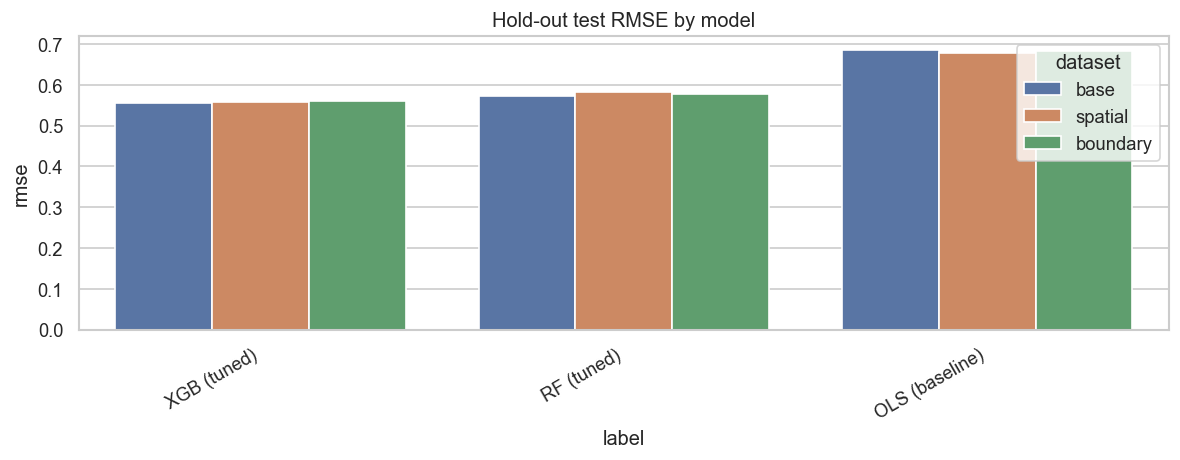

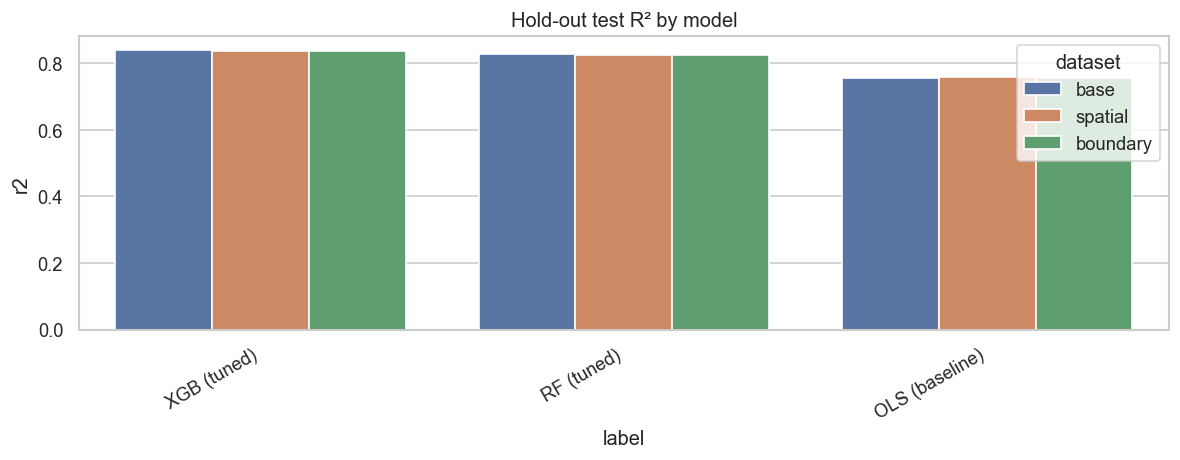

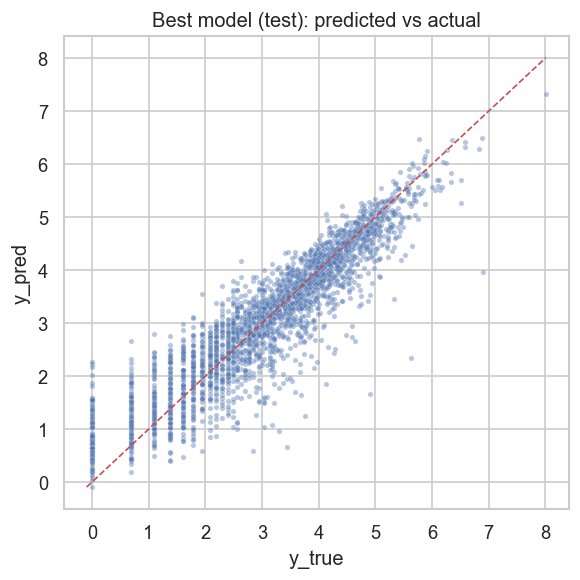

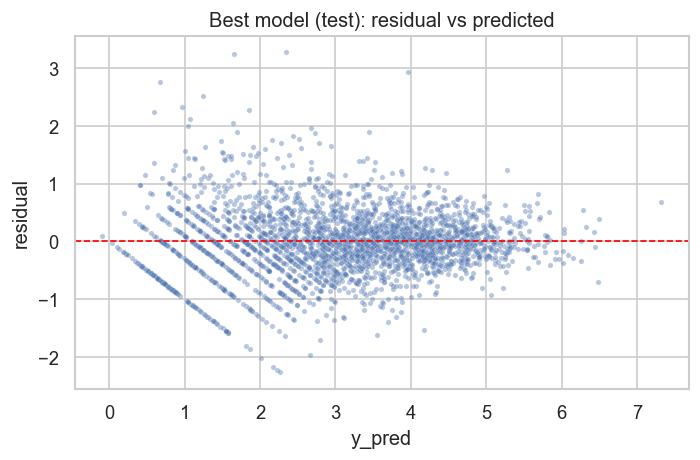

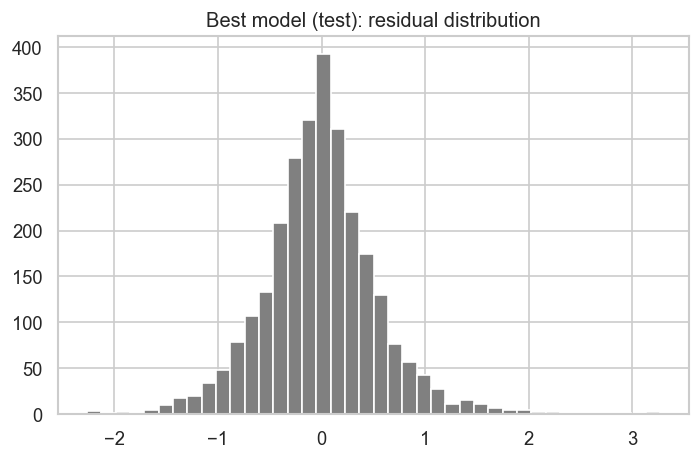

In [44]:
# Build X/y for test split using the same feature-selection logic
X_base_test, y_base_test, _ = select_numeric_predictors(base_test_df, TARGET_COL, ID_COLS_BASE)
X_queen_test, y_queen_test, _ = select_numeric_predictors(queen_test_df, TARGET_COL, ID_COLS_QUEEN)
X_boundary_test, y_boundary_test, _ = select_numeric_predictors(boundary_test_df, TARGET_COL, ID_COLS_BOUNDARY)

# Align columns explicitly (train defines the feature space)
X_base_test = X_base_test.reindex(columns=X_base.columns, fill_value=np.nan)
X_queen_test = X_queen_test.reindex(columns=X_queen.columns, fill_value=np.nan)
X_boundary_test = X_boundary_test.reindex(columns=X_boundary.columns, fill_value=np.nan)

print("\nTrain/Test shapes:")
print("Base train:", X_base.shape, "Base test:", X_base_test.shape)
print("Queen train:", X_queen.shape, "Queen test:", X_queen_test.shape)
print("Boundary train:", X_boundary.shape, "Boundary test:", X_boundary_test.shape)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def fit_predict_eval(model: Pipeline, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    rmse = float(np.sqrt(mean_squared_error(yte, pred)))
    mae = float(mean_absolute_error(yte, pred))
    r2 = float(r2_score(yte, pred))
    return pred, rmse, mae, r2

results = []
preds = []

# Context columns for richer diagnostics
ctx_cols = [c for c in ["gwb_code_10", "gm_naam", "regio", "a_inw", "crime_count"] if c in base_test_df.columns]
ctx_base_test = base_test_df[ctx_cols].copy() if ctx_cols else pd.DataFrame(index=base_test_df.index)
ctx_queen_test = queen_test_df[ctx_cols].copy() if ctx_cols else pd.DataFrame(index=queen_test_df.index)
ctx_boundary_test = boundary_test_df[ctx_cols].copy() if ctx_cols else pd.DataFrame(index=boundary_test_df.index)

# OLS (baseline)
for dataset_type, (Xtr, ytr, Xte, yte, ctx) in {
    "base": (X_base, y_base, X_base_test, y_base_test, ctx_base_test),
    "queen": (X_queen, y_queen, X_queen_test, y_queen_test, ctx_queen_test),
    "boundary": (X_boundary, y_boundary, X_boundary_test, y_boundary_test, ctx_boundary_test),
}.items():
    pred, rmse, mae, r2 = fit_predict_eval(make_ols_pipeline(), Xtr, ytr, Xte, yte)
    results.append({"model": "OLS", "dataset": dataset_type, "tuning": "baseline", "rmse": rmse, "mae": mae, "r2": r2})
    dfp = ctx.copy()
    dfp["dataset"] = dataset_type
    dfp["model"] = "OLS"
    dfp["tuning"] = "baseline"
    dfp["y_true"] = yte.values
    dfp["y_pred"] = pred
    dfp["residual"] = dfp["y_true"] - dfp["y_pred"]
    dfp["abs_error"] = dfp["residual"].abs()
    preds.append(dfp)

# RF tuned
pred, rmse, mae, r2 = fit_predict_eval(rf_best_base, X_base, y_base, X_base_test, y_base_test)
results.append({"model": "RF", "dataset": "base", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_base_test.copy(); dfp["dataset"]="base"; dfp["model"]="RF"; dfp["tuning"]="tuned"; dfp["y_true"]=y_base_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

pred, rmse, mae, r2 = fit_predict_eval(rf_best_queen, X_queen, y_queen, X_queen_test, y_queen_test)
results.append({"model": "RF", "dataset": "queen", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_queen_test.copy(); dfp["dataset"]="queen"; dfp["model"]="RF"; dfp["tuning"]="tuned"; dfp["y_true"]=y_queen_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

pred, rmse, mae, r2 = fit_predict_eval(rf_best_boundary, X_boundary, y_boundary, X_boundary_test, y_boundary_test)
results.append({"model": "RF", "dataset": "boundary", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_boundary_test.copy(); dfp["dataset"]="boundary"; dfp["model"]="RF"; dfp["tuning"]="tuned"; dfp["y_true"]=y_boundary_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

# XGB tuned
pred, rmse, mae, r2 = fit_predict_eval(xgb_best_base, X_base, y_base, X_base_test, y_base_test)
results.append({"model": "XGB", "dataset": "base", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_base_test.copy(); dfp["dataset"]="base"; dfp["model"]="XGB"; dfp["tuning"]="tuned"; dfp["y_true"]=y_base_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

pred, rmse, mae, r2 = fit_predict_eval(xgb_best_queen, X_queen, y_queen, X_queen_test, y_queen_test)
results.append({"model": "XGB", "dataset": "queen", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_queen_test.copy(); dfp["dataset"]="queen"; dfp["model"]="XGB"; dfp["tuning"]="tuned"; dfp["y_true"]=y_queen_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

pred, rmse, mae, r2 = fit_predict_eval(xgb_best_boundary, X_boundary, y_boundary, X_boundary_test, y_boundary_test)
results.append({"model": "XGB", "dataset": "boundary", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_boundary_test.copy(); dfp["dataset"]="boundary"; dfp["model"]="XGB"; dfp["tuning"]="tuned"; dfp["y_true"]=y_boundary_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

final_test = pd.DataFrame(results).sort_values(["rmse", "model", "dataset"]).reset_index(drop=True)
print("\n=== Hold-out test set performance (RMSE / MAE / R²) ===")
print(final_test.to_string(index=False))

test_preds_all = pd.concat(preds, ignore_index=True)

# Persist test-set predictions so notebook 6 can reuse them.
# (Notebook 6 expects these column names.)
# Keep the original columns for plotting/filtering in this notebook, and create copies for notebook 6.
if "dataset" in test_preds_all.columns and "dataset_type" not in test_preds_all.columns:
    test_preds_all["dataset_type"] = test_preds_all["dataset"].astype(str)
if "tuning" in test_preds_all.columns and "tuning_status" not in test_preds_all.columns:
    test_preds_all["tuning_status"] = test_preds_all["tuning"].astype(str)

OUT_MODEL_DIR = Path("outputs") / "modeling"
OUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
final_test.to_csv(OUT_MODEL_DIR / "final_test_set_results.csv", index=False)
test_preds_all.to_csv(OUT_MODEL_DIR / "test_set_predictions_all_models.csv", index=False)
print("\nSaved:", OUT_MODEL_DIR / "final_test_set_results.csv")
print("Saved:", OUT_MODEL_DIR / "test_set_predictions_all_models.csv")

# Quick comparison plots (shown; not saved)
plt.figure(figsize=(10, 4))
plot_df = final_test.copy()
plot_df["label"] = plot_df["model"] + " (" + plot_df["tuning"] + ")"
sns.barplot(data=plot_df, x="label", y="rmse", hue="dataset", errorbar=None)
plt.title("Hold-out test RMSE by model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="label", y="r2", hue="dataset", errorbar=None)
plt.title("Hold-out test R² by model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Best model on test (lowest RMSE)
best_row = final_test.iloc[0]

# Robust filtering in case columns were renamed.
ds_col = "dataset" if "dataset" in test_preds_all.columns else "dataset_type"
tu_col = "tuning" if "tuning" in test_preds_all.columns else "tuning_status"

best_test = test_preds_all[
    (test_preds_all["model"] == best_row["model"]) &
    (test_preds_all[ds_col] == best_row["dataset"]) &
    (test_preds_all[tu_col] == best_row["tuning"])
].copy()

plt.figure(figsize=(5, 5))
sns.scatterplot(x=best_test["y_true"], y=best_test["y_pred"], s=10, alpha=0.4)
mn = min(best_test["y_true"].min(), best_test["y_pred"].min())
mx = max(best_test["y_true"].max(), best_test["y_pred"].max())
plt.plot([mn, mx], [mn, mx], "r--", lw=1)
plt.title("Best model (test): predicted vs actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(x=best_test["y_pred"], y=best_test["residual"], s=10, alpha=0.4)
plt.axhline(0, color="red", ls="--", lw=1)
plt.title("Best model (test): residual vs predicted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(best_test["residual"], bins=40, color="gray", edgecolor="white")
plt.title("Best model (test): residual distribution")
plt.tight_layout()
plt.show()

### SHAP values

/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_65325/3318779502.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_s, feature_names=list(Xte.columns), show=False)


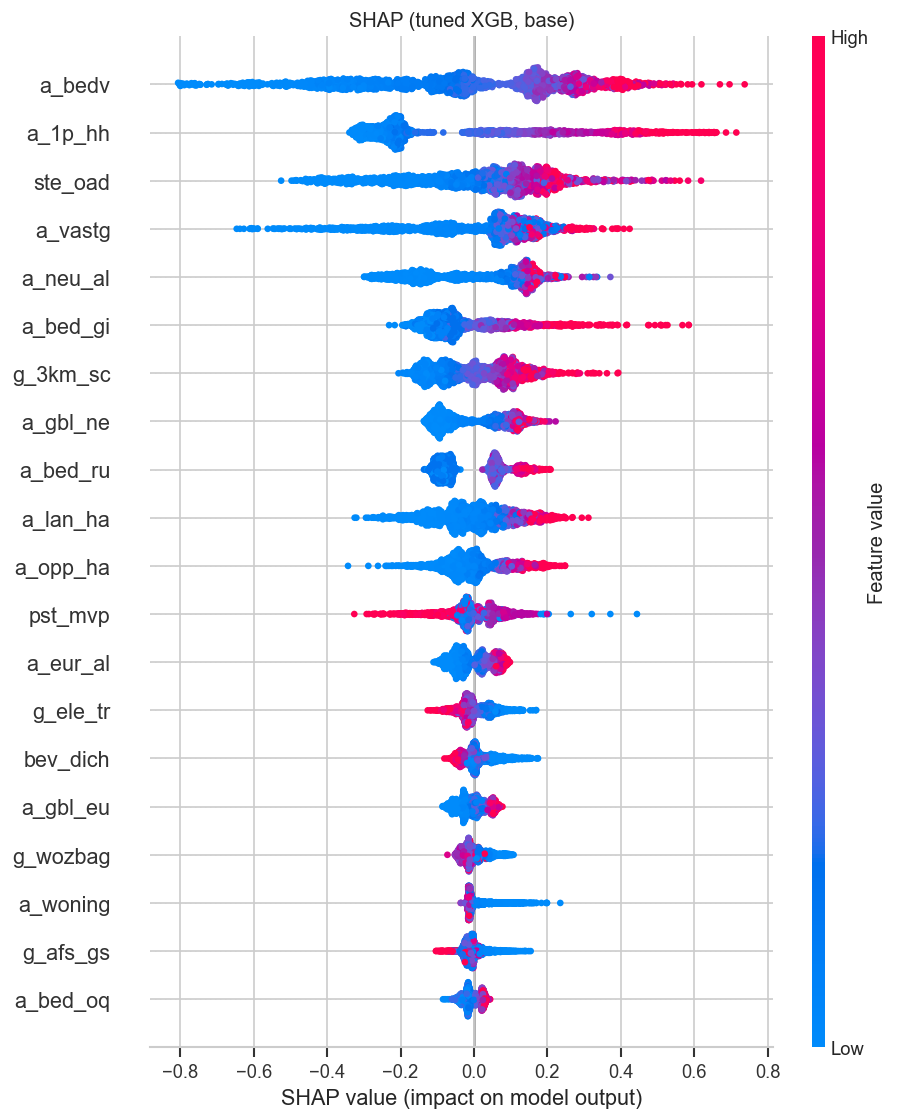

,feature,mean_abs_shap
0,a_bedv,0.248982
1,a_1p_hh,0.243744
2,ste_oad,0.157111
3,a_vastg,0.146734
4,a_neu_al,0.136078
5,a_bed_gi,0.098144
6,g_3km_sc,0.091762
7,a_gbl_ne,0.087810
8,a_bed_ru,0.083811
9,a_lan_ha,0.082649


/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_65325/3318779502.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_s, feature_names=list(Xte.columns), show=False)


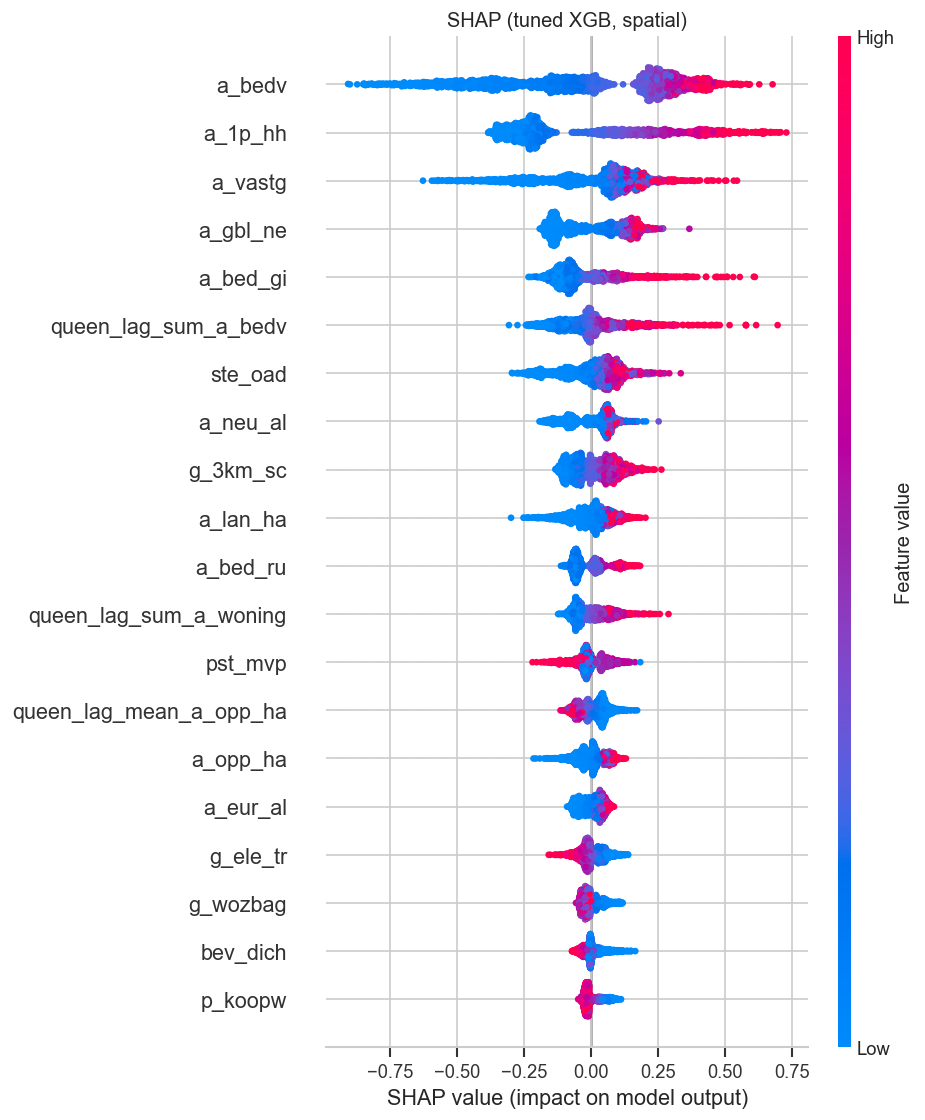

,feature,mean_abs_shap
0,a_bedv,0.284251
1,a_1p_hh,0.256140
2,a_vastg,0.148859
3,a_gbl_ne,0.118369
4,a_bed_gi,0.097404
5,queen_lag_sum_a_bedv,0.083377
6,ste_oad,0.079039
7,a_neu_al,0.069355
8,g_3km_sc,0.067754
9,a_lan_ha,0.054238


/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_65325/3318779502.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_s, feature_names=list(Xte.columns), show=False)


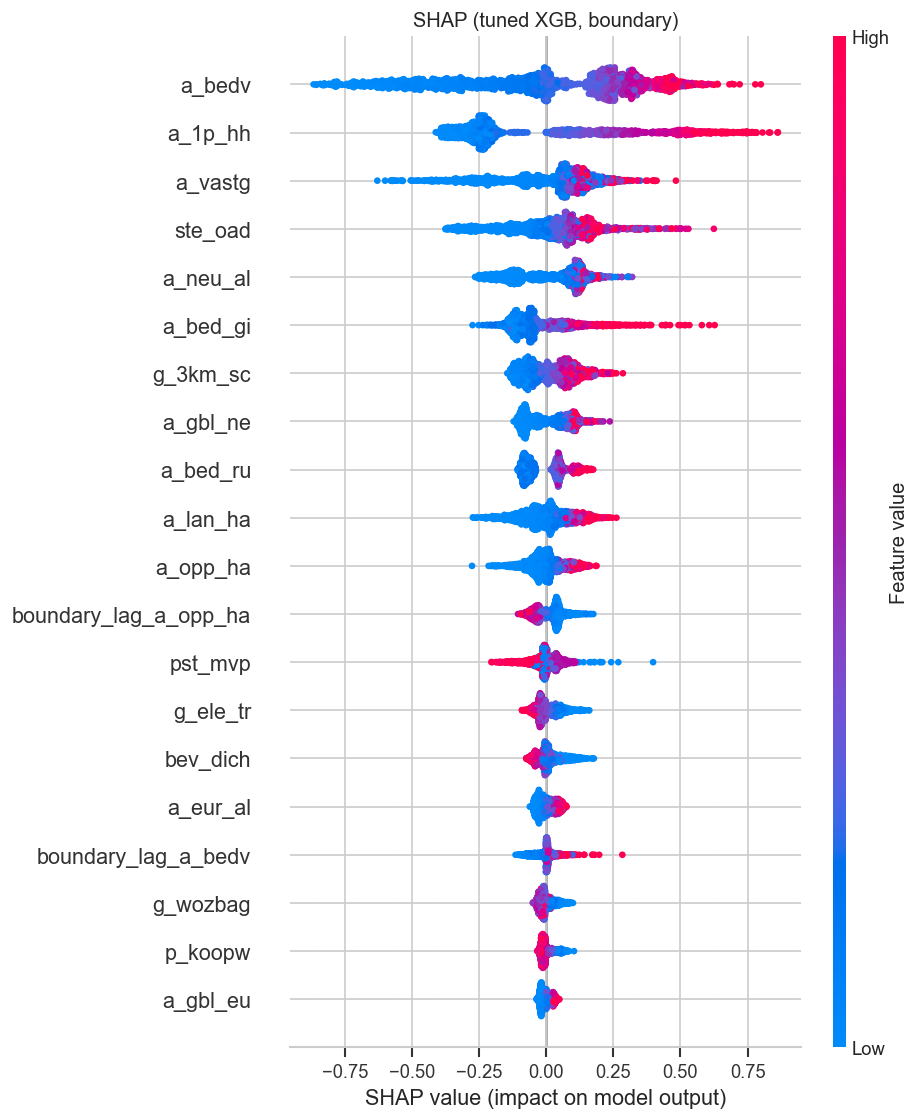

,feature,mean_abs_shap
0,a_bedv,0.290240
1,a_1p_hh,0.285834
2,a_vastg,0.136839
3,ste_oad,0.119655
4,a_neu_al,0.115059
5,a_bed_gi,0.094030
6,g_3km_sc,0.076159
7,a_gbl_ne,0.074445
8,a_bed_ru,0.069288
9,a_lan_ha,0.068576


In [47]:
import shap

def shap_for_tuned_xgb(pipe: Pipeline, Xtr, ytr, Xte, title: str):
    full = Pipeline(steps=pipe.steps)
    full.fit(Xtr, ytr)

    imputer = full.named_steps["imputer"]
    model = full.named_steps["model"]

    X_imp = imputer.transform(Xte)

    rng = np.random.RandomState(RANDOM_STATE)
    n = X_imp.shape[0]
    sample_n = min(2000, n)
    idx = rng.choice(n, size=sample_n, replace=False)
    X_s = X_imp[idx]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_s)

    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values, X_s, feature_names=list(Xte.columns), show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_df = (
        pd.DataFrame({"feature": list(Xte.columns), "mean_abs_shap": mean_abs})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    display(shap_df.head(25))
    return shap_df

shap_df_xgb_base = shap_for_tuned_xgb(xgb_best_base, X_base, y_base, X_base_test, "SHAP (tuned XGB, base)")
shap_df_xgb_queen = shap_for_tuned_xgb(xgb_best_queen, X_queen, y_queen, X_queen_test, "SHAP (tuned XGB, queen)")
shap_df_xgb_boundary = shap_for_tuned_xgb(xgb_best_boundary, X_boundary, y_boundary, X_boundary_test, "SHAP (tuned XGB, boundary)")

In [8]:
print("Number of predictor features used:")
print(f"- Base:     {X_base.shape[1]} features")
print(f"- Queen:    {X_queen.shape[1]} features")
print(f"- Boundary: {X_boundary.shape[1]} features")

Number of predictor features used:
- Base:     83 features
- Spatial:  95 features
- Boundary: 89 features


## Sensitivity analysis — reduced feature sets (missingness-threshold)

This section re-runs the evaluation on **reduced** versions of the three datasets produced by notebook 4. The reduced datasets differ from the full datasets **only** by removing variables that were retained despite exceeding the missingness-threshold filter.

We use the exact same municipality-grouped train/test split and evaluation protocol as above.

In [ ]:
# Load reduced datasets (produced by notebook 4)
REDUCED_BASE_PATH = DATA_DIR / "model_ready_base_reduced.csv"
REDUCED_QUEEN_PATH = DATA_DIR / "model_ready_queen_reduced.csv"
REDUCED_BOUNDARY_PATH = DATA_DIR / "model_ready_boundary_reduced.csv"

base_df_full_reduced = pd.read_csv(REDUCED_BASE_PATH, low_memory=False)
queen_df_full_reduced = pd.read_csv(REDUCED_QUEEN_PATH, low_memory=False)
boundary_df_full_reduced = pd.read_csv(REDUCED_BOUNDARY_PATH, low_memory=False)

# Use the exact same municipality split as the full run (test_munis computed above)
base_train_red, base_test_red = split_by_muni(base_df_full_reduced)
queen_train_red, queen_test_red = split_by_muni(queen_df_full_reduced)
boundary_train_red, boundary_test_red = split_by_muni(boundary_df_full_reduced)

# Sanity: confirm the split is consistent across reduced datasets
base_train_munis_red = set(base_train_red[GROUP_COL].dropna().unique().tolist())
queen_train_munis_red = set(queen_train_red[GROUP_COL].dropna().unique().tolist())
boundary_train_munis_red = set(boundary_train_red[GROUP_COL].dropna().unique().tolist())

base_test_munis_red = set(base_test_red[GROUP_COL].dropna().unique().tolist())
queen_test_munis_red = set(queen_test_red[GROUP_COL].dropna().unique().tolist())
boundary_test_munis_red = set(boundary_test_red[GROUP_COL].dropna().unique().tolist())

print("\n=== Reduced-dataset split audit ===")
print("Train muni sets match across datasets:", base_train_munis_red == queen_train_munis_red == boundary_train_munis_red)
print("Test muni sets match across datasets:", base_test_munis_red == queen_test_munis_red == boundary_test_munis_red)

# Build X/y for reduced train/test using the same feature-selection logic
X_base_red, y_base_red, _ = select_numeric_predictors(base_train_red, TARGET_COL, ID_COLS_BASE)
X_queen_red, y_queen_red, _ = select_numeric_predictors(queen_train_red, TARGET_COL, ID_COLS_QUEEN)
X_boundary_red, y_boundary_red, _ = select_numeric_predictors(boundary_train_red, TARGET_COL, ID_COLS_BOUNDARY)

X_base_test_red, y_base_test_red, _ = select_numeric_predictors(base_test_red, TARGET_COL, ID_COLS_BASE)
X_queen_test_red, y_queen_test_red, _ = select_numeric_predictors(queen_test_red, TARGET_COL, ID_COLS_QUEEN)
X_boundary_test_red, y_boundary_test_red, _ = select_numeric_predictors(boundary_test_red, TARGET_COL, ID_COLS_BOUNDARY)

# Align columns explicitly (train defines the feature space)
X_base_test_red = X_base_test_red.reindex(columns=X_base_red.columns, fill_value=np.nan)
X_queen_test_red = X_queen_test_red.reindex(columns=X_queen_red.columns, fill_value=np.nan)
X_boundary_test_red = X_boundary_test_red.reindex(columns=X_boundary_red.columns, fill_value=np.nan)

print("\nReduced Train/Test shapes:")
print("Base:", X_base_red.shape, "->", X_base_test_red.shape)
print("Queen:", X_queen_red.shape, "->", X_queen_test_red.shape)
print("Boundary:", X_boundary_red.shape, "->", X_boundary_test_red.shape)

# Evaluate full vs reduced on the held-out test set.
# For RF/XGB tuned models we reuse the same tuned hyperparameters discovered above, but refit on the reduced training split.

results_reduced = []

# OLS baseline
for ds, (Xtr, ytr, Xte, yte) in {
    "base": (X_base_red, y_base_red, X_base_test_red, y_base_test_red),
    "queen": (X_queen_red, y_queen_red, X_queen_test_red, y_queen_test_red),
    "boundary": (X_boundary_red, y_boundary_red, X_boundary_test_red, y_boundary_test_red),
}.items():
    pred, rmse, mae, r2 = fit_predict_eval(make_ols_pipeline(), Xtr, ytr, Xte, yte)
    results_reduced.append({"model": "OLS", "dataset": ds, "tuning": "mvp", "rmse": rmse, "mae": mae, "r2": r2})

# RF (mvp)
for ds, (Xtr, ytr, Xte, yte) in {
    "base": (X_base_red, y_base_red, X_base_test_red, y_base_test_red),
    "queen": (X_queen_red, y_queen_red, X_queen_test_red, y_queen_test_red),
    "boundary": (X_boundary_red, y_boundary_red, X_boundary_test_red, y_boundary_test_red),
}.items():
    pred, rmse, mae, r2 = fit_predict_eval(make_rf_pipeline(), Xtr, ytr, Xte, yte)
    results_reduced.append({"model": "RF", "dataset": ds, "tuning": "mvp", "rmse": rmse, "mae": mae, "r2": r2})

# RF (tuned)
if "rf_best_base" in globals() and "rf_best_queen" in globals() and "rf_best_boundary" in globals():
    for ds, (best_pipe, Xtr, ytr, Xte, yte) in {
        "base": (rf_best_base, X_base_red, y_base_red, X_base_test_red, y_base_test_red),
        "queen": (rf_best_queen, X_queen_red, y_queen_red, X_queen_test_red, y_queen_test_red),
        "boundary": (rf_best_boundary, X_boundary_red, y_boundary_red, X_boundary_test_red, y_boundary_test_red),
    }.items():
        pred, rmse, mae, r2 = fit_predict_eval(best_pipe, Xtr, ytr, Xte, yte)
        results_reduced.append({"model": "RF", "dataset": ds, "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})

# XGB (mvp + tuned)
if XGBOOST_AVAILABLE:
    for ds, (Xtr, ytr, Xte, yte) in {
        "base": (X_base_red, y_base_red, X_base_test_red, y_base_test_red),
        "queen": (X_queen_red, y_queen_red, X_queen_test_red, y_queen_test_red),
        "boundary": (X_boundary_red, y_boundary_red, X_boundary_test_red, y_boundary_test_red),
    }.items():
        pred, rmse, mae, r2 = fit_predict_eval(make_xgb_pipeline(), Xtr, ytr, Xte, yte)
        results_reduced.append({"model": "XGB", "dataset": ds, "tuning": "mvp", "rmse": rmse, "mae": mae, "r2": r2})

    if "xgb_best_base" in globals() and "xgb_best_queen" in globals() and "xgb_best_boundary" in globals():
        for ds, (best_pipe, Xtr, ytr, Xte, yte) in {
            "base": (xgb_best_base, X_base_red, y_base_red, X_base_test_red, y_base_test_red),
            "queen": (xgb_best_queen, X_queen_red, y_queen_red, X_queen_test_red, y_queen_test_red),
            "boundary": (xgb_best_boundary, X_boundary_red, y_boundary_red, X_boundary_test_red, y_boundary_test_red),
        }.items():
            pred, rmse, mae, r2 = fit_predict_eval(best_pipe, Xtr, ytr, Xte, yte)
            results_reduced.append({"model": "XGB", "dataset": ds, "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})

reduced_results_df = pd.DataFrame(results_reduced)

SENS_OUT = MODEL_OUT_DIR / "sensitivity_reduced_final_test_set_results.csv"
SENS_OUT.parent.mkdir(parents=True, exist_ok=True)
reduced_results_df.to_csv(SENS_OUT, index=False)
print("\nWrote:", SENS_OUT)

# Compact comparison table: full vs reduced
full_results_path = MODEL_OUT_DIR / "final_test_set_results.csv"
full_results_df = pd.read_csv(full_results_path)

comp = (
    full_results_df.merge(
        reduced_results_df,
        on=["model", "dataset", "tuning"],
        how="inner",
        suffixes=("_full", "_reduced"),
    )
    .assign(
        delta_rmse=lambda d: d["rmse_reduced"] - d["rmse_full"],
        delta_r2=lambda d: d["r2_reduced"] - d["r2_full"],
    )
    [[
        "model",
        "dataset",
        "tuning",
        "rmse_full",
        "rmse_reduced",
        "delta_rmse",
        "r2_full",
        "r2_reduced",
        "delta_r2",
    ]]
    .sort_values(["rmse_full", "model", "dataset", "tuning"])
)

display(comp)

# Save comparison table
comp_out = MODEL_OUT_DIR / "sensitivity_reduced_comparison_table.csv"
comp.to_csv(comp_out, index=False)
print("Wrote:", comp_out)

# Quick figures to support the sensitivity analysis
plt.figure(figsize=(8, 4))
plt.axhline(0, color="black", linewidth=1)
plt.bar(
    [f"{m}-{ds}-{t}" for m, ds, t in comp[["model", "dataset", "tuning"]].itertuples(index=False, name=None)],
    comp["delta_rmse"].values,
)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Δ RMSE (reduced - full)")
plt.title("Sensitivity: RMSE change after dropping protected high-missingness variables")
plt.tight_layout()
fig1 = MODEL_OUT_DIR / "fig_sensitivity_delta_rmse.png"
plt.savefig(fig1, dpi=200)
plt.show()
print("Saved:", fig1)

plt.figure(figsize=(8, 4))
plt.axhline(0, color="black", linewidth=1)
plt.bar(
    [f"{m}-{ds}-{t}" for m, ds, t in comp[["model", "dataset", "tuning"]].itertuples(index=False, name=None)],
    comp["delta_r2"].values,
)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Δ R² (reduced - full)")
plt.title("Sensitivity: R² change after dropping protected high-missingness variables")
plt.tight_layout()
fig2 = MODEL_OUT_DIR / "fig_sensitivity_delta_r2.png"
plt.savefig(fig2, dpi=200)
plt.show()
print("Saved:", fig2)


## Outputs saved

### Train/test splits (written to `datasets/model_ready/`)
Created using a municipality-grouped 80/20 split (`random_state=42`):
- `datasets/model_ready/model_ready_base_train.csv` / `datasets/model_ready/model_ready_base_test.csv`
- `datasets/model_ready/model_ready_queen_train.csv` / `datasets/model_ready/model_ready_queen_test.csv`
- `datasets/model_ready/model_ready_boundary_train.csv` / `datasets/model_ready/model_ready_boundary_test.csv`

### Modeling results (written to `outputs/modeling/`)
- `outputs/modeling/final_test_set_results.csv` (RMSE / MAE / R² for all 9 configurations)
- `outputs/modeling/test_set_predictions_all_models.csv` (row-level held-out test predictions for all 9 configurations)

### Sensitivity analysis outputs (reduced feature sets; written to `outputs/modeling/`)
- `outputs/modeling/sensitivity_reduced_final_test_set_results.csv`
- `outputs/modeling/sensitivity_reduced_comparison_table.csv`
- `outputs/modeling/fig_sensitivity_delta_rmse.png`
- `outputs/modeling/fig_sensitivity_delta_r2.png`